# Freddie Mac — 10F CatBoost risk ranking and chronological validation

Evaluate the **saved** 10-feature CatBoost for 24-month serious-credit-event risk. The model itself is not overwritten. The original 80/20 stratified holdout is reconstructed within the earlier Train cohort; five-fold out-of-fold (OOF) scores are computed only on its 80% fitting portion. The later Validation cohort is evaluated in chronological order (2017-04 to 2018-03). No label from either holdout is used to choose bands.

Run from top to bottom in the environment that can import `helpers` and load the existing pickle. OOF requires five extra CatBoost fits. Outputs are saved under `importance/ranking_validation`. All code and plot labels are in English.

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.stats import norm
from sklearn.base import clone
from sklearn.metrics import average_precision_score, roc_auc_score, roc_curve, brier_score_loss
from sklearn.model_selection import StratifiedKFold, train_test_split
from helpers import *

PROJECT_ROOT = Path(
    r"C:\Users\itwill\Desktop\study\코딩공부\프로젝트"
    r"\The Single Family Loan-Level Dataset (SFLLD) - 6"
)
PROJECT_NAME = "SFLLD_M8_11F_DTI_Missing_3models_controlled_fixed12Fparams"
MODEL_PATH = PROJECT_ROOT / "notebooks" / PROJECT_NAME / "importance" / "catboost_no_harp_10F_fixed.pkl"
DATA_DIR = PROJECT_ROOT / "data" / "output" / "model_ready"
TRAIN_PATH = DATA_DIR / "SFLLD_regular_PIT_train_ML_ready.parquet"
VALIDATION_PATH = DATA_DIR / "SFLLD_regular_PIT_validation_ML_ready.parquet"
OUT_DIR = MODEL_PATH.parent / "ranking_validation"
OUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 3217
TARGET = "Target_24M"
DATE = "First_Payment_Date"
ID = "Loan_ID"
FEATURES_10F = [
    "FICO_Score", "Original_DTI", "Original_CLTV", "Original_Interest_Rate",
    "Number_of_Borrowers", "DTI_Missing", "Spatial_Cluster_Region",
    "Housing_HPI_Growth_12M", "BLS_Unemployment_Rate_Change_12M_Final",
    "Regular_MSA_Macro_Cluster_A",
]
CATEGORICAL_10F = ["DTI_Missing", "Spatial_Cluster_Region", "Regular_MSA_Macro_Cluster_A"]
BAND_SHARES = [0.05, 0.15, 0.30, 0.50]  # Highest risk first; set before inspecting holdouts.
BAND_NAMES = ["Very High (top 5%)", "High (next 15%)", "Medium (next 30%)", "Low (remaining 50%)"]
TOP_SHARES = [0.01, 0.05, 0.10, 0.20]

for path in [MODEL_PATH, TRAIN_PATH, VALIDATION_PATH]:
    if not path.is_file():
        raise FileNotFoundError(f"Required file not found: {path}")

estimator = my_ml.load_model(MODEL_PATH)
train_df = pd.read_parquet(TRAIN_PATH)
validation_df = pd.read_parquet(VALIDATION_PATH)
print("Model:", MODEL_PATH)
print("Train cohort:", TRAIN_PATH, train_df.shape)
print("Validation cohort:", VALIDATION_PATH, validation_df.shape)
print("Outputs:", OUT_DIR)

Model: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\notebooks\SFLLD_M8_11F_DTI_Missing_3models_controlled_fixed12Fparams\importance\catboost_no_harp_10F_fixed.pkl
Train cohort: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\output\model_ready\SFLLD_regular_PIT_train_ML_ready.parquet (160003, 56)
Validation cohort: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\output\model_ready\SFLLD_regular_PIT_validation_ML_ready.parquet (49038, 56)
Outputs: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\notebooks\SFLLD_M8_11F_DTI_Missing_3models_controlled_fixed12Fparams\importance\ranking_validation


## 1. Data and model gates

The loan's first-payment month defines the existing chronological cohort. The model uses only the ten listed predictors; dates and loan IDs are audit columns. This notebook checks the saved artifact's actual feature order and categorical dtypes. It cannot independently reconstruct the full upstream preprocessing lineage from two parquet files.

In [2]:
def normalize_date(series):
    if pd.api.types.is_datetime64_any_dtype(series):
        return pd.to_datetime(series, errors="coerce")
    numeric = pd.to_numeric(series, errors="coerce")
    if numeric.notna().all() and numeric.between(190001, 210012).all():
        return pd.to_datetime(numeric.astype("int64").astype(str), format="%Y%m", errors="coerce")
    return pd.to_datetime(series, errors="coerce")

for cohort_name, frame, lower, upper in [
    ("Train", train_df, "2014-01-01", "2017-03-01"),
    ("Validation", validation_df, "2017-04-01", "2018-03-01"),
]:
    required = FEATURES_10F + [TARGET, DATE, ID]
    missing = sorted(set(required) - set(frame.columns))
    if missing:
        raise KeyError(f"{cohort_name}: missing columns {missing}. Inspect ML-ready artifact lineage.")
    frame[DATE] = normalize_date(frame[DATE])
    if frame[DATE].isna().any():
        raise ValueError(f"{cohort_name}: invalid or missing first-payment dates")
    if not frame[DATE].dt.to_period("M").dt.to_timestamp().between(lower, upper).all():
        raise AssertionError(f"{cohort_name} date range does not match the notebook's chronological split")
    if frame[ID].isna().any() or not frame[ID].is_unique:
        raise AssertionError(f"{cohort_name}: Loan_ID is missing or duplicated")
    if frame[TARGET].isna().any() or not set(frame[TARGET].unique()).issubset({0, 1}):
        raise AssertionError(f"{cohort_name}: invalid 24-month target")
    if frame[FEATURES_10F].isna().any().any():
        raise ValueError(f"{cohort_name}: selected model feature has missing values")
    if "Split" in frame and not frame["Split"].astype(str).eq(cohort_name).all():
        raise AssertionError(f"{cohort_name}: unexpected Split labels")

if set(train_df[ID]).intersection(set(validation_df[ID])):
    raise AssertionError("Train and Validation share one or more Loan_ID values")
if not train_df[DATE].max() < validation_df[DATE].min():
    raise AssertionError("Chronological order failed")

model_features = list(estimator.named_steps["model"].feature_names_)
if set(model_features) != set(FEATURES_10F) or len(model_features) != 10:
    raise AssertionError(f"Unexpected saved model features: {model_features}")

for frame in [train_df, validation_df]:
    converted = my_qtcheck.set_type(frame, as_category=CATEGORICAL_10F)
    frame[CATEGORICAL_10F] = converted[CATEGORICAL_10F]
    for col in CATEGORICAL_10F:
        if not isinstance(frame[col].dtype, pd.CategoricalDtype):
            raise TypeError(f"{col} did not become categorical")

for col in CATEGORICAL_10F:
    unseen = set(validation_df[col].dropna().astype(str)) - set(train_df[col].dropna().astype(str))
    if unseen:
        raise ValueError(f"Validation has unseen {col} levels: {sorted(unseen)}")

audit = pd.DataFrame([
    {"Cohort": name, "N": len(f), "Events": int(f[TARGET].sum()),
     "Event_Rate": f[TARGET].mean(), "First_Payment_Min": f[DATE].min(),
     "First_Payment_Max": f[DATE].max(), "Loan_ID_Unique": f[ID].is_unique}
    for name, f in [("Train cohort", train_df), ("Chronological Validation", validation_df)]
])
display(audit)
print("Saved model feature order:", model_features)
print("All chronological, ID, target, feature, and categorical gates passed.")
audit.to_csv(OUT_DIR / "cohort_audit.csv", index=False)

<class 'pandas.DataFrame'>
RangeIndex: 160003 entries, 0 to 160002
Data columns (total 56 columns):
 #   Column                                  Non-Null Count   Dtype         
---  ------                                  --------------   -----         
 0   Loan_ID                                 160003 non-null  str           
 1   FICO_Score                              160003 non-null  float64       
 2   First_Payment_Date                      160003 non-null  datetime64[us]
 3   First_Time_Homebuyer                    160003 non-null  int64         
 4   Maturity_Date                           160003 non-null  datetime64[us]
 5   MSA                                     160003 non-null  int64         
 6   MI_Percentage                           160003 non-null  float64       
 7   Number_of_Units                         160003 non-null  int64         
 8   Occupancy_Status                        160003 non-null  int64         
 9   Original_CLTV                           160003 n

,Cohort,N,Events,Event_Rate,First_Payment_Min,First_Payment_Max,Loan_ID_Unique
0,Train cohort,160003,919,0.005744,2014-01-01,2017-03-01,True
1,Chronological Validation,49038,380,0.007749,2017-04-01,2018-03-01,True


Saved model feature order: ['FICO_Score', 'Original_DTI', 'Original_CLTV', 'Original_Interest_Rate', 'Number_of_Borrowers', 'Housing_HPI_Growth_12M', 'BLS_Unemployment_Rate_Change_12M_Final', 'DTI_Missing', 'Spatial_Cluster_Region', 'Regular_MSA_Macro_Cluster_A']
All chronological, ID, target, feature, and categorical gates passed.


## 2. Reconstruct the original internal holdout; generate training-only OOF scores

Fit five fresh clones with the **same fixed estimator configuration** solely to get OOF predictions. The saved 10F model remains unchanged. The original internal test and chronological Validation never enter those fits. Preserve the model's actual column order when scoring. If the original fitted model used a different 80/20 split or feature transformations, stop and reconcile before interpreting results.

In [3]:
X_all = train_df[model_features].copy()
y_all = train_df[TARGET].astype(int).copy()
X_fit, X_holdout, y_fit, y_holdout = train_test_split(
    X_all, y_all, test_size=0.20, random_state=RANDOM_STATE, stratify=y_all
)
X_validation = validation_df[model_features].copy()
y_validation = validation_df[TARGET].astype(int).copy()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_scores = pd.Series(np.nan, index=X_fit.index, dtype=float)
for fold, (fit_pos, out_pos) in enumerate(cv.split(X_fit, y_fit), start=1):
    fold_model = clone(estimator)
    fold_model.fit(
        X_fit.iloc[fit_pos], y_fit.iloc[fit_pos],
        model__cat_features=CATEGORICAL_10F,
    )
    oof_scores.iloc[out_pos] = fold_model.predict_proba(X_fit.iloc[out_pos])[:, 1]
    print(f"OOF fold {fold}: {len(fit_pos):,} fit / {len(out_pos):,} scored")
if oof_scores.isna().any():
    raise AssertionError("Missing OOF scores")

holdout_scores = pd.Series(estimator.predict_proba(X_holdout)[:, 1], index=X_holdout.index)
validation_scores = pd.Series(estimator.predict_proba(X_validation)[:, 1], index=X_validation.index)
fit_model_scores = pd.Series(estimator.predict_proba(X_fit)[:, 1], index=X_fit.index)

scored = {
    "Train OOF": (y_fit, oof_scores),
    "Internal held-out test": (y_holdout, holdout_scores),
    "Chronological Validation": (y_validation, validation_scores),
}
for name, (y, s) in scored.items():
    if len(y) != len(s) or not y.index.equals(s.index) or not np.isfinite(s.to_numpy()).all():
        raise AssertionError(f"Invalid score/index alignment: {name}")
print("Saved model untouched; all scores aligned to their labels.")

OOF fold 1: 102,401 fit / 25,601 scored
OOF fold 2: 102,401 fit / 25,601 scored
OOF fold 3: 102,402 fit / 25,600 scored
OOF fold 4: 102,402 fit / 25,600 scored
OOF fold 5: 102,402 fit / 25,600 scored
Saved model untouched; all scores aligned to their labels.


## 3. Ranking metrics and capacity-based capture

KS is the maximum difference between true-positive and false-positive rates over thresholds. Gini = 2 × ROC-AUC − 1. Precision at Top-K is the observed event rate of the selected segment, not a probability calibration measure. Report each cohort's baseline prevalence alongside PR-AUC.

,Dataset,N,Events,Prevalence,ROC_AUC,Gini,KS,PR_AUC_AP,Brier
0,Train OOF,128002,735,0.005742,0.829643,0.659287,0.497678,0.036120,0.005625
1,Internal held-out test,32001,184,0.005750,0.855422,0.710844,0.572938,0.047680,0.005605
2,Chronological Validation,49038,380,0.007749,0.825323,0.650645,0.518644,0.041518,0.007566


,Top_Share,Selected_N,Selected_Events,Event_Rate,Capture_Rate,Lift_vs_Cohort,Dataset
0,0.01,1281,83,0.064793,0.112925,11.283878,Train OOF
1,0.05,6401,244,0.038119,0.331973,6.638522,Train OOF
2,0.10,12801,357,0.027888,0.485714,4.856839,Train OOF
3,0.20,25601,503,0.019648,0.684354,3.421689,Train OOF
4,0.01,321,22,0.068536,0.119565,11.919646,Internal held-out test
5,0.05,1601,66,0.041224,0.358696,7.169656,Internal held-out test
6,0.10,3201,96,0.029991,0.521739,5.215924,Internal held-out test
7,0.20,6401,139,0.021715,0.755435,3.776702,Internal held-out test
8,0.01,491,38,0.077393,0.100000,9.987373,Chronological Validation
9,0.05,2452,114,0.046493,0.300000,5.999755,Chronological Validation


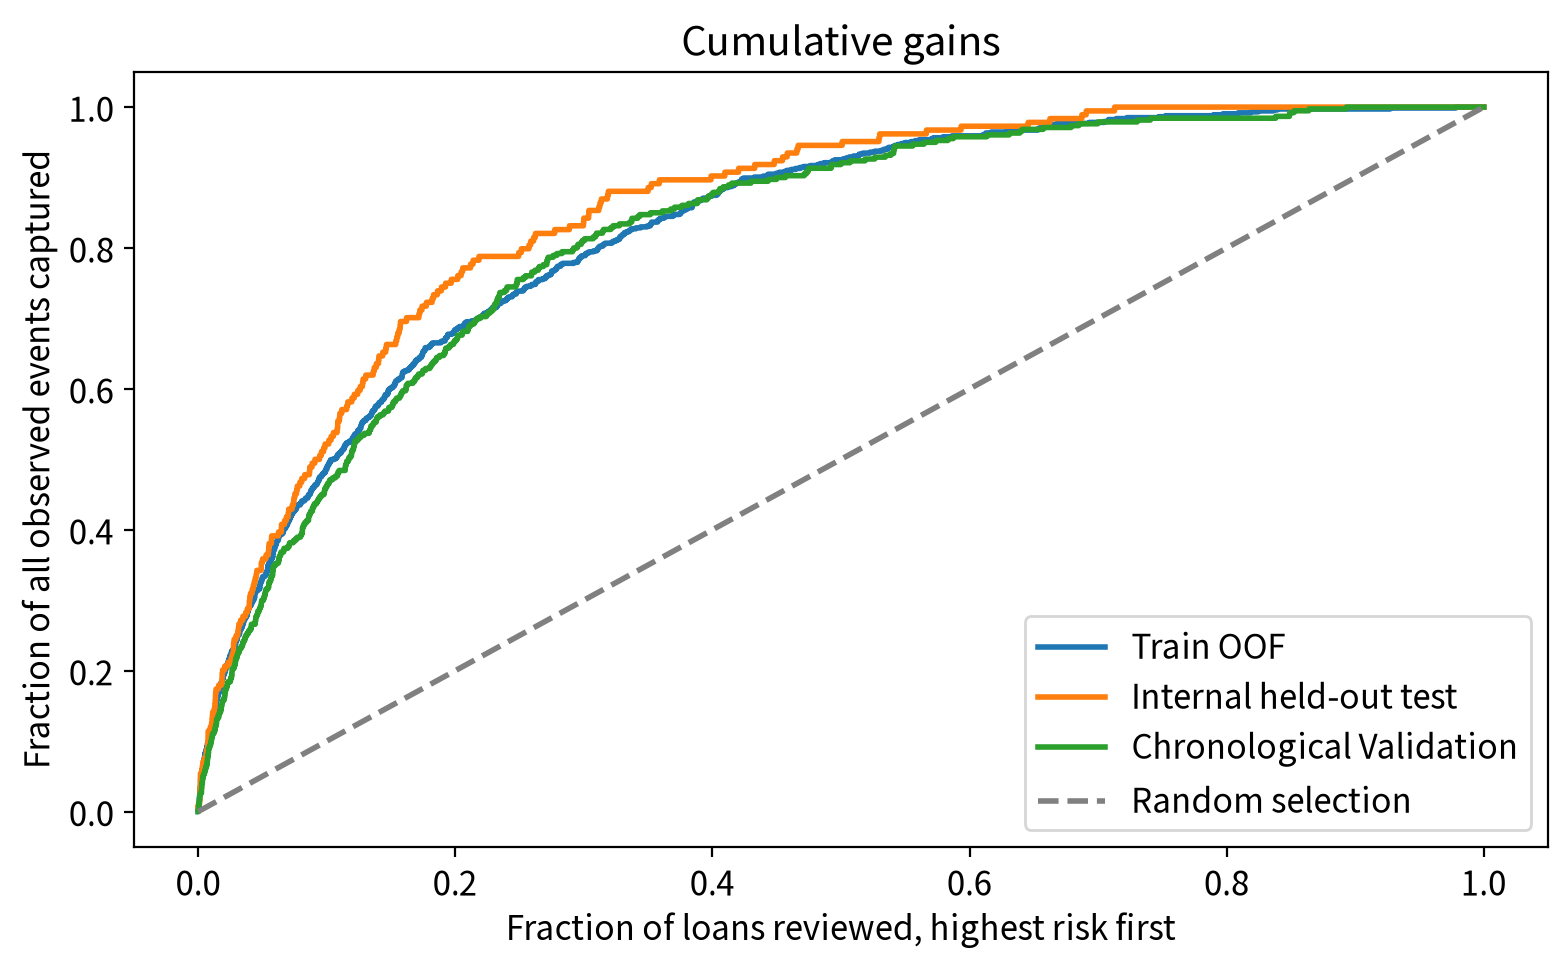

In [4]:
def ranking_metrics(y, score):
    yt, s = np.asarray(y, dtype=int), np.asarray(score, dtype=float)
    fpr, tpr, _ = roc_curve(yt, s)
    auc = roc_auc_score(yt, s)
    return {"N": len(yt), "Events": int(yt.sum()), "Prevalence": yt.mean(),
            "ROC_AUC": auc, "Gini": 2 * auc - 1, "KS": np.max(tpr - fpr),
            "PR_AUC_AP": average_precision_score(yt, s),
            "Brier": brier_score_loss(yt, s)}

metrics = pd.DataFrame([{"Dataset": name, **ranking_metrics(y, s)} for name, (y, s) in scored.items()])
display(metrics)
metrics.to_csv(OUT_DIR / "ranking_metrics.csv", index=False)

def top_share_table(y, score, shares=TOP_SHARES):
    yt, s = np.asarray(y, dtype=int), np.asarray(score, dtype=float)
    order = np.argsort(-s, kind="stable")
    base = yt.mean()
    rows = []
    for share in shares:
        n = max(1, int(np.ceil(len(yt) * share)))
        events = int(yt[order[:n]].sum())
        rows.append({"Top_Share": share, "Selected_N": n, "Selected_Events": events,
                     "Event_Rate": events / n, "Capture_Rate": events / yt.sum(),
                     "Lift_vs_Cohort": (events / n) / base})
    return pd.DataFrame(rows)

capacity = pd.concat([top_share_table(y, s).assign(Dataset=name)
                      for name, (y, s) in scored.items()], ignore_index=True)
display(capacity)
capacity.to_csv(OUT_DIR / "top_k_capacity.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 5))
for name, (y, s) in scored.items():
    sorted_events = np.asarray(y, dtype=int)[np.argsort(-np.asarray(s), kind="stable")]
    x = np.arange(1, len(y) + 1) / len(y)
    ax.plot(x, np.cumsum(sorted_events) / sum(y), label=name)
ax.plot([0, 1], [0, 1], "--", color="gray", label="Random selection")
ax.set(xlabel="Fraction of loans reviewed, highest risk first", ylabel="Fraction of all observed events captured", title="Cumulative gains")
ax.legend(); fig.tight_layout(); fig.savefig(OUT_DIR / "cumulative_gains.png", dpi=160); plt.show()

## 4. Risk bands: fixed capacity, observed lift, and a cutoff diagnostic

Primary band assignment uses each cohort's **scores only** to select the planned capacity shares (5% / 15% / 30% / 50%); labels are never consulted. This is a relative, batch-specific rule, so numeric cutoffs can change between cohorts. A secondary fixed-score rule uses OOF quantiles; because OOF fold models and the saved full-fit model can have different score scales, its population shares are **diagnostic**, not an approved operational policy. Confidence intervals and event counts matter more than perfect sample monotonicity.

,Dataset,Method,Band,N,Share,Events,Event_Rate,Rate_CI95_Low,Rate_CI95_High,Lift_vs_Cohort,Capture_Rate,Score_Min,Score_Max
0,Train OOF,Within-cohort score percentile,Very High (top 5%),6401,0.050007,244,0.038119,0.033698,0.043094,6.638522,0.331973,0.021024,0.429680
1,Train OOF,Within-cohort score percentile,High (next 15%),19200,0.149998,259,0.013490,0.011952,0.015221,2.349243,0.352381,0.007696,0.021023
2,Train OOF,Within-cohort score percentile,Medium (next 30%),38400,0.299995,177,0.004609,0.003980,0.005338,0.802734,0.240816,0.002638,0.007695
3,Train OOF,Within-cohort score percentile,Low (remaining 50%),64001,0.500000,55,0.000859,0.000660,0.001118,0.149660,0.074830,0.000052,0.002638
4,Internal held-out test,Within-cohort score percentile,Very High (top 5%),1601,0.050030,66,0.041224,0.032534,0.052111,7.169656,0.358696,0.020074,0.321951
5,Internal held-out test,Within-cohort score percentile,High (next 15%),4800,0.149995,73,0.015208,0.012114,0.019078,2.645010,0.396739,0.007590,0.020072
6,Internal held-out test,Within-cohort score percentile,Medium (next 30%),9600,0.299991,35,0.003646,0.002623,0.005066,0.634078,0.190217,0.002664,0.007589
7,Internal held-out test,Within-cohort score percentile,Low (remaining 50%),16000,0.499984,10,0.000625,0.000340,0.001150,0.108699,0.054348,0.000102,0.002664
8,Chronological Validation,Within-cohort score percentile,Very High (top 5%),2452,0.050002,114,0.046493,0.038845,0.055559,5.999755,0.300000,0.022131,0.221618
9,Chronological Validation,Within-cohort score percentile,High (next 15%),7356,0.150006,140,0.019032,0.016151,0.022415,2.456040,0.368421,0.009389,0.022121


OOF numeric cutoffs (top 5%, top 20%, top 50%): [0.02102437 0.00769561 0.00263805]


,Dataset,Method,Band,N,Share,Events,Event_Rate,Rate_CI95_Low,Rate_CI95_High,Lift_vs_Cohort,Capture_Rate,Score_Min,Score_Max
0,Train OOF,Frozen OOF score cutoffs (diagnostic),Very High (top 5%),6401,0.050007,244,0.038119,0.033698,0.043094,6.638522,0.331973,0.021024,0.429680
1,Train OOF,Frozen OOF score cutoffs (diagnostic),High (next 15%),19200,0.149998,259,0.013490,0.011952,0.015221,2.349243,0.352381,0.007696,0.021023
2,Train OOF,Frozen OOF score cutoffs (diagnostic),Medium (next 30%),38400,0.299995,177,0.004609,0.003980,0.005338,0.802734,0.240816,0.002638,0.007695
3,Train OOF,Frozen OOF score cutoffs (diagnostic),Low (remaining 50%),64001,0.500000,55,0.000859,0.000660,0.001118,0.149660,0.074830,0.000052,0.002638
4,Internal held-out test,Frozen OOF score cutoffs (diagnostic),Very High (top 5%),1489,0.046530,63,0.042310,0.033209,0.053767,7.358539,0.342391,0.021038,0.321951
5,Internal held-out test,Frozen OOF score cutoffs (diagnostic),High (next 15%),4814,0.150433,76,0.015787,0.012632,0.019714,2.745701,0.413043,0.007696,0.021021
6,Internal held-out test,Frozen OOF score cutoffs (diagnostic),Medium (next 30%),9798,0.306178,36,0.003674,0.002655,0.005082,0.639015,0.195652,0.002639,0.007693
7,Internal held-out test,Frozen OOF score cutoffs (diagnostic),Low (remaining 50%),15900,0.496859,9,0.000566,0.000298,0.001076,0.098444,0.048913,0.000102,0.002638
8,Chronological Validation,Frozen OOF score cutoffs (diagnostic),Very High (top 5%),2705,0.055161,124,0.045841,0.038583,0.054387,5.915665,0.326316,0.021026,0.221618
9,Chronological Validation,Frozen OOF score cutoffs (diagnostic),High (next 15%),9614,0.196052,163,0.016954,0.014560,0.019735,2.187926,0.428947,0.007696,0.021024


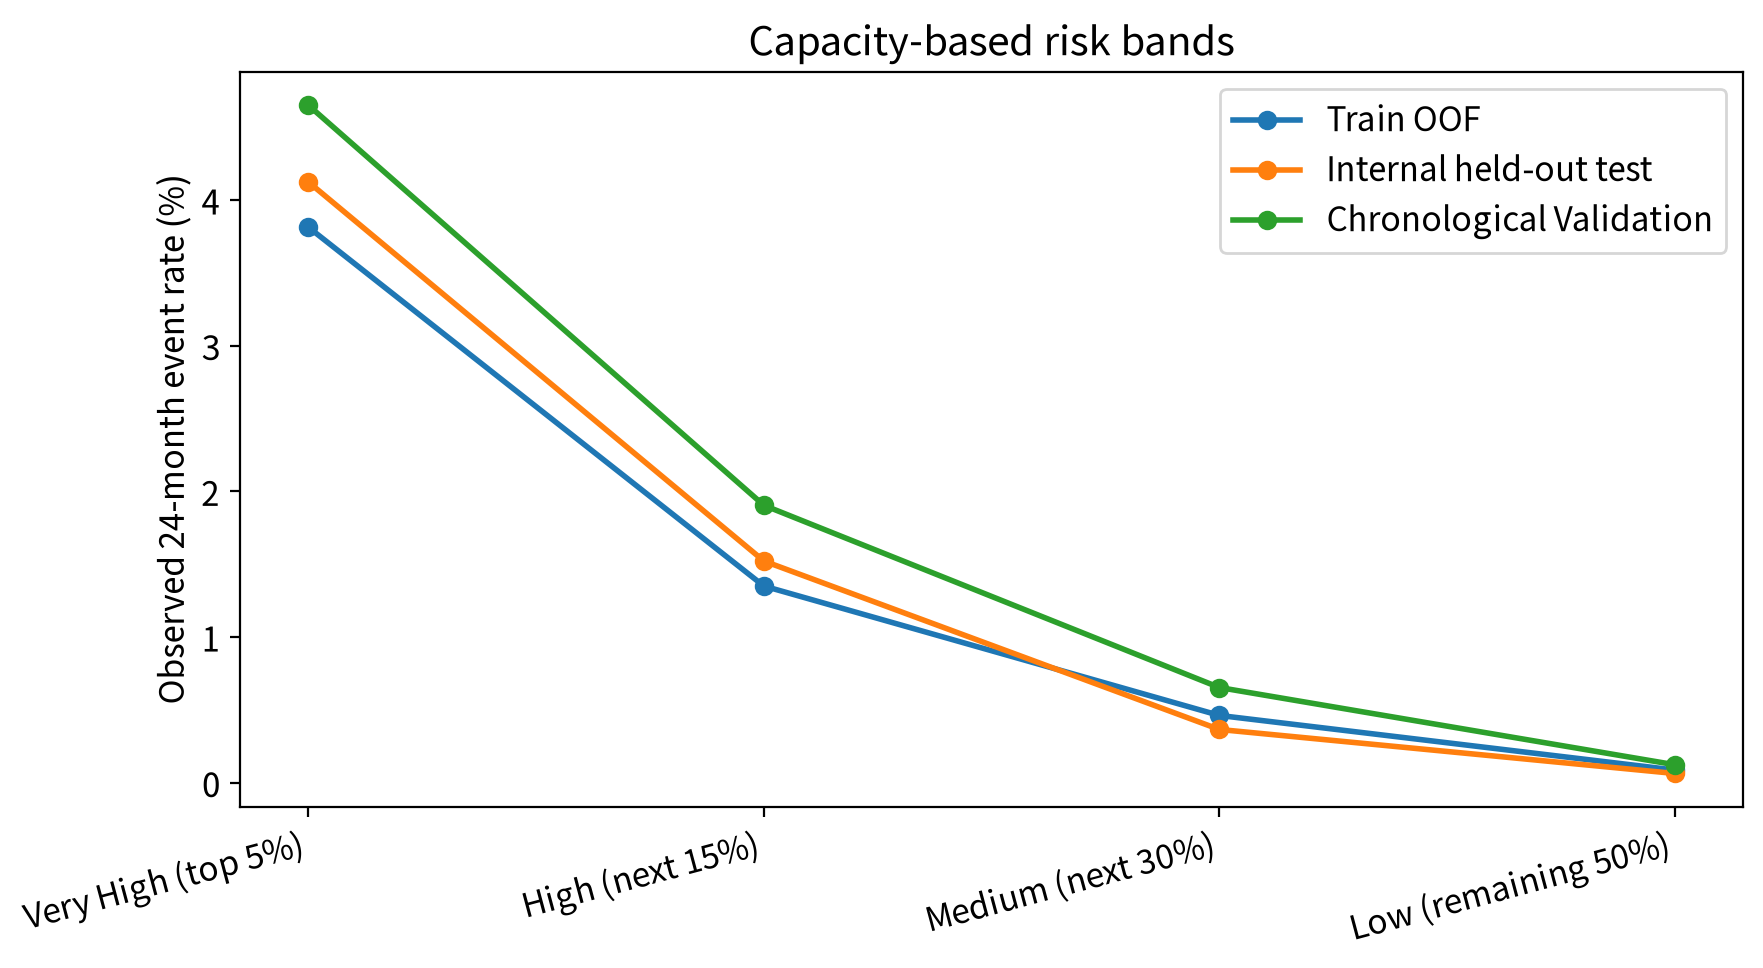

In [5]:
def wilson_interval(k, n, alpha=0.05):
    if n == 0:
        return np.nan, np.nan
    z = norm.ppf(1 - alpha / 2)
    p = k / n
    d = 1 + z*z/n
    center = (p + z*z/(2*n))/d
    half = z*np.sqrt(p*(1-p)/n + z*z/(4*n*n))/d
    return max(0, center-half), min(1, center+half)

def band_summary(y, s, band_index, dataset, method):
    yt, score = np.asarray(y, dtype=int), np.asarray(s, dtype=float)
    rows = []
    for i, name in enumerate(BAND_NAMES):
        chosen = band_index == i
        n, events = int(chosen.sum()), int(yt[chosen].sum())
        lo, hi = wilson_interval(events, n)
        rows.append({"Dataset": dataset, "Method": method, "Band": name, "N": n,
                     "Share": n/len(yt), "Events": events, "Event_Rate": events/n if n else np.nan,
                     "Rate_CI95_Low": lo, "Rate_CI95_High": hi,
                     "Lift_vs_Cohort": (events/n)/yt.mean() if n else np.nan,
                     "Capture_Rate": events/yt.sum(),
                     "Score_Min": score[chosen].min() if n else np.nan,
                     "Score_Max": score[chosen].max() if n else np.nan})
    return pd.DataFrame(rows)

def capacity_bands(scores):
    scores = np.asarray(scores, dtype=float)
    order = np.argsort(-scores, kind="stable")
    rank = np.empty(len(scores), dtype=int)
    rank[order] = np.arange(len(scores))
    return np.searchsorted(np.cumsum(BAND_SHARES[:-1]), rank/len(scores), side="right")

capacity_bands_table = pd.concat([
    band_summary(y, s, capacity_bands(s), name, "Within-cohort score percentile")
    for name, (y, s) in scored.items()
], ignore_index=True)
display(capacity_bands_table)
capacity_bands_table.to_csv(OUT_DIR / "capacity_risk_bands.csv", index=False)

# Numeric boundaries are frozen using only the development OOF scores.
q = np.cumsum(BAND_SHARES[:-1])
oof_cutoffs = np.quantile(oof_scores, 1 - q)
if not np.all(np.diff(oof_cutoffs) <= 0):
    raise AssertionError("Unexpected cutoff order")
print("OOF numeric cutoffs (top 5%, top 20%, top 50%):", oof_cutoffs)

def numeric_bands(scores, cutoffs):
    arr = np.asarray(scores, dtype=float)
    return np.select([arr >= cutoffs[0], arr >= cutoffs[1], arr >= cutoffs[2]], [0, 1, 2], default=3)

fixed_bands_table = pd.concat([
    band_summary(y, s, numeric_bands(s, oof_cutoffs), name, "Frozen OOF score cutoffs (diagnostic)")
    for name, (y, s) in scored.items()
], ignore_index=True)
display(fixed_bands_table)
fixed_bands_table.to_csv(OUT_DIR / "fixed_score_cutoff_diagnostic.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 5))
for name in scored:
    part = capacity_bands_table.query("Dataset == @name")
    ax.plot(range(4), 100*part["Event_Rate"], marker="o", label=name)
ax.set_xticks(range(4), BAND_NAMES, rotation=15, ha="right")
ax.set(ylabel="Observed 24-month event rate (%)", title="Capacity-based risk bands")
ax.legend(); fig.tight_layout(); fig.savefig(OUT_DIR / "risk_band_event_rates.png", dpi=160); plt.show()

## 5. Probability calibration and score-scale checks

Observed event rate by risk band tests **discrimination**. A probability calibration curve instead compares numeric predicted probability with observed frequency. These are distinct questions. With rare events, use score quantiles to retain enough observations, report event counts, and treat sparse bins cautiously. Brier score is reported beside discrimination metrics; this notebook does not refit a calibrator.

,bin,N,Events,Predicted_Mean,Actual_Event_Rate,Score_Min,Score_Max,Dataset,Rate_CI95_Low,Rate_CI95_High
0,0,12801,2,0.000396,0.000156,0.000052,0.000584,Train OOF,4.284708e-05,0.000570
1,1,12800,5,0.000754,0.000391,0.000584,0.000931,Train OOF,1.668628e-04,0.000914
2,2,12800,9,0.001143,0.000703,0.000931,0.001375,Train OOF,3.699702e-04,0.001336
3,3,12800,14,0.001647,0.001094,0.001375,0.001939,Train OOF,6.516589e-04,0.001835
4,4,12800,25,0.002271,0.001953,0.001939,0.002638,Train OOF,1.323341e-03,0.002882
5,5,12800,37,0.003079,0.002891,0.002638,0.003582,Train OOF,2.097966e-03,0.003982
6,6,12800,63,0.004255,0.004922,0.003582,0.005058,Train OOF,3.849151e-03,0.006292
7,7,12800,77,0.006234,0.006016,0.005059,0.007695,Train OOF,4.816264e-03,0.007511
8,8,12800,146,0.010117,0.011406,0.007696,0.013514,Train OOF,9.707683e-03,0.013398
9,9,12801,357,0.026996,0.027888,0.013516,0.429680,Train OOF,2.517469e-02,0.030885


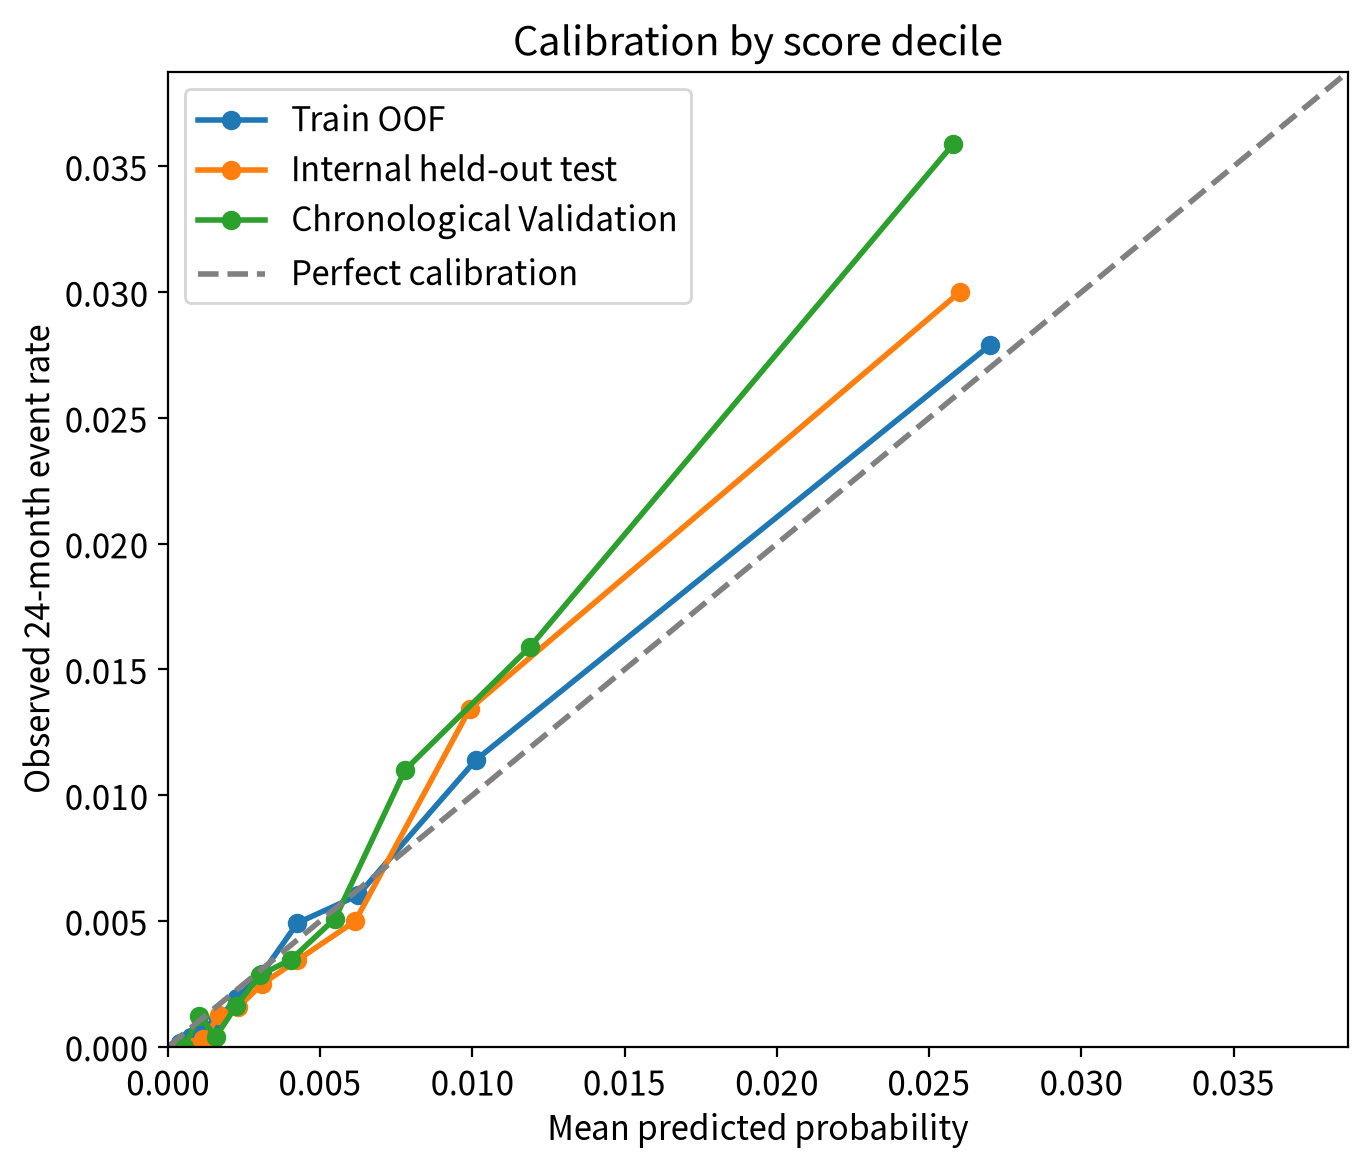

,Score_Source,N,q01,q05,q25,q50,q75,q95,q99
0,Train OOF (fold models),128002,0.000223,0.000408,0.001137,0.002638,0.006166,0.021024,0.044994
1,Train fit (saved model; in-sample),128002,0.000222,0.000409,0.001146,0.002666,0.006197,0.021036,0.044640
2,Internal held-out (saved model),32001,0.000225,0.000414,0.001161,0.002664,0.006097,0.020074,0.043336
3,Chronological Validation (saved model),49038,0.000309,0.000556,0.001570,0.003486,0.007732,0.022123,0.039773


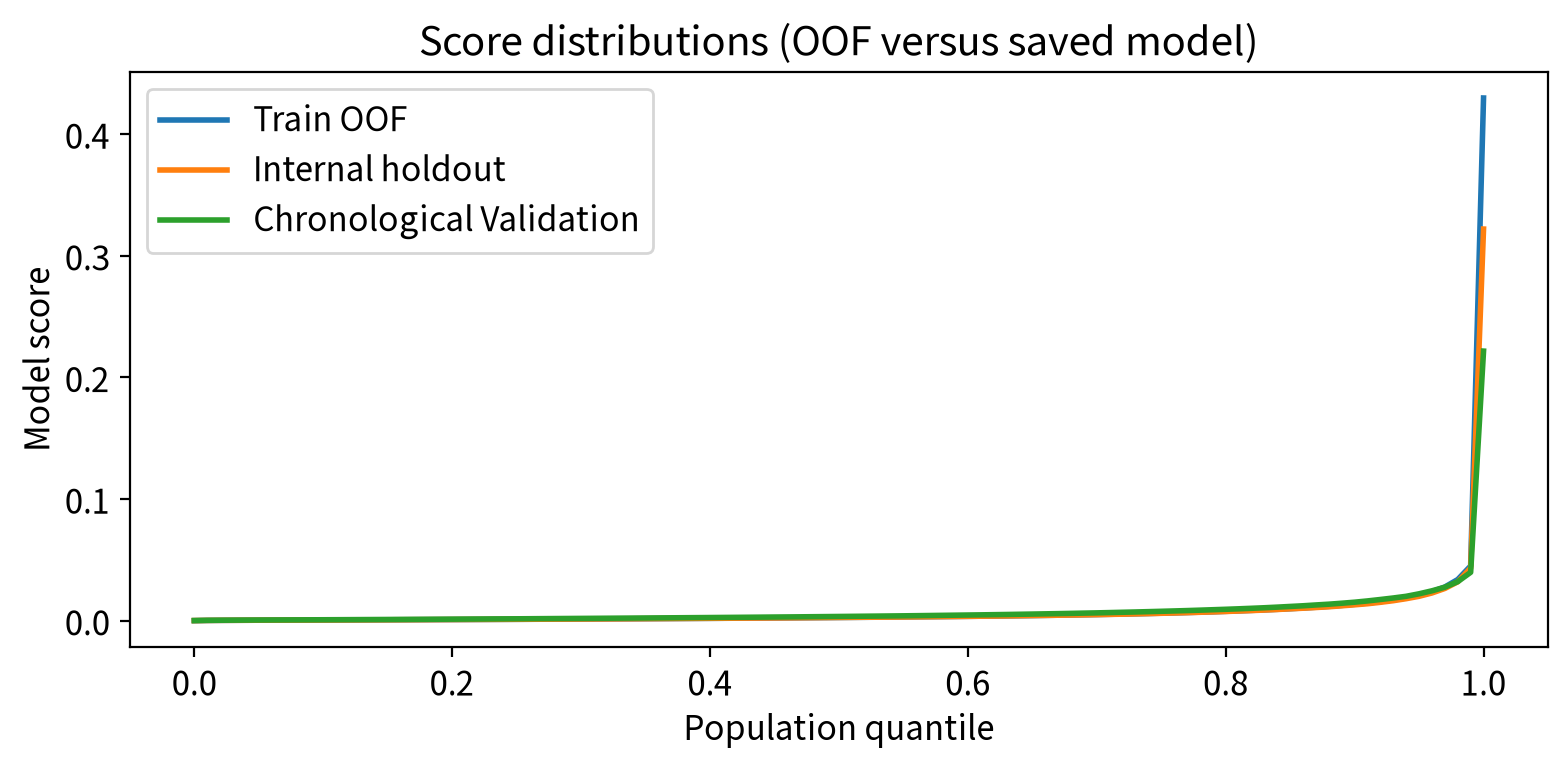

In [6]:
def calibration_table(y, score, dataset, n_bins=10):
    frame = pd.DataFrame({"y": np.asarray(y, dtype=int), "score": np.asarray(score, dtype=float)})
    frame["bin"] = pd.qcut(frame["score"].rank(method="first"), q=n_bins, labels=False)
    out = frame.groupby("bin", observed=True).agg(
        N=("y", "size"), Events=("y", "sum"), Predicted_Mean=("score", "mean"),
        Actual_Event_Rate=("y", "mean"), Score_Min=("score", "min"), Score_Max=("score", "max")
    ).reset_index()
    out["Dataset"] = dataset
    ci = [wilson_interval(int(k), int(n)) for k, n in zip(out.Events, out.N)]
    out["Rate_CI95_Low"] = [v[0] for v in ci]
    out["Rate_CI95_High"] = [v[1] for v in ci]
    return out

calibration = pd.concat([calibration_table(y, s, name) for name, (y, s) in scored.items()], ignore_index=True)
display(calibration)
calibration.to_csv(OUT_DIR / "calibration_by_decile.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 6))
for name in scored:
    part = calibration.query("Dataset == @name")
    ax.plot(part["Predicted_Mean"], part["Actual_Event_Rate"], "o-", label=name)
end = max(calibration[["Predicted_Mean", "Actual_Event_Rate"]].max()) * 1.08
ax.plot([0, end], [0, end], "--", color="gray", label="Perfect calibration")
ax.set(xlabel="Mean predicted probability", ylabel="Observed 24-month event rate", title="Calibration by score decile", xlim=(0, end), ylim=(0, end))
ax.legend(); fig.tight_layout(); fig.savefig(OUT_DIR / "calibration_deciles.png", dpi=160); plt.show()

score_scale = pd.DataFrame([
    {"Score_Source": name, "N": len(s), **{f"q{int(q*100):02d}": np.quantile(s, q) for q in [.01,.05,.25,.5,.75,.95,.99]}}
    for name, s in [("Train OOF (fold models)", oof_scores),
                    ("Train fit (saved model; in-sample)", fit_model_scores),
                    ("Internal held-out (saved model)", holdout_scores),
                    ("Chronological Validation (saved model)", validation_scores)]
])
display(score_scale)
score_scale.to_csv(OUT_DIR / "score_scale_comparison.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4))
for name, s in [("Train OOF", oof_scores), ("Internal holdout", holdout_scores), ("Chronological Validation", validation_scores)]:
    ax.plot(np.linspace(0, 1, 101), np.quantile(s, np.linspace(0, 1, 101)), label=name)
ax.set(xlabel="Population quantile", ylabel="Model score", title="Score distributions (OOF versus saved model)")
ax.legend(); fig.tight_layout(); fig.savefig(OUT_DIR / "score_quantiles.png", dpi=160); plt.show()

## 6. Population Stability Index (PSI) and interpretation

PSI compares score distributions, not predictive validity. Bin edges come from the **saved model's Train-fit scores**, making them directly comparable to the saved model's holdout/Validation scores (but the Train-fit scores are in-sample). OOF-to-final-model PSI is excluded because those scores come from different fitted models. There is no universal PSI pass/fail threshold; score shifts require investigation alongside cohort composition, lift, and calibration.

In [7]:
def psi(reference, comparison, n_bins=10):
    ref, cmp = np.asarray(reference, dtype=float), np.asarray(comparison, dtype=float)
    edges = np.unique(np.quantile(ref, np.linspace(0, 1, n_bins+1)))
    if len(edges) < 3:
        raise ValueError("Too few unique scores for PSI bins")
    edges[0], edges[-1] = -np.inf, np.inf
    r = np.histogram(ref, bins=edges)[0] / len(ref)
    c = np.histogram(cmp, bins=edges)[0] / len(cmp)
    # Explicit smoothing prevents undefined log terms in an empty bin.
    eps = 1e-6
    rr, cc = np.maximum(r, eps), np.maximum(c, eps)
    contributions = (cc-rr)*np.log(cc/rr)
    details = pd.DataFrame({"Bin": np.arange(1,len(r)+1), "Reference_Share": r,
                            "Comparison_Share": c, "PSI_Contribution": contributions})
    return float(contributions.sum()), details

psi_rows = []
for name, s in [("Internal held-out test", holdout_scores), ("Chronological Validation", validation_scores)]:
    value, bins = psi(fit_model_scores, s)
    psi_rows.append({"Reference": "Train-fit scores from saved model", "Comparison": name, "PSI": value})
    bins.to_csv(OUT_DIR / ("psi_bins_" + name.lower().replace(" ", "_") + ".csv"), index=False)
psi_report = pd.DataFrame(psi_rows)
display(psi_report)
psi_report.to_csv(OUT_DIR / "psi_summary.csv", index=False)

,Reference,Comparison,PSI
0,Train-fit scores from saved model,Internal held-out test,0.000587
1,Train-fit scores from saved model,Chronological Validation,0.051881


## 7. Review checklist and frozen settings

- The Validation cohort is chronologically later and its labels are only used for evaluation.
- The current saved model must be traceable to fitting on the Train cohort's **original 80% internal fit subset**. A pickle alone does not prove fit membership; verify its creation notebook.
- Band shares are prespecified, and per-cohort percentiles use only scores. The OOF-derived **absolute** score cutoffs are diagnostic until full-fit score-scale compatibility is established.
- Individual risk bands need their event counts and confidence intervals; a small apparent inversion is not automatically a failed model.
- This notebook measures the existing CatBoost's chronological transfer. It does not establish probability calibration, profitability, fairness, or performance in a later macro regime.
- Monthly score PSI can be monitored immediately after deployment; 24-month event-rate validation needs matured outcomes. Any earlier 6/12-month proxy requires a separately defined label and analysis.

In [8]:
settings = {
    "model_path": str(MODEL_PATH), "train_path": str(TRAIN_PATH),
    "validation_path": str(VALIDATION_PATH), "random_state": RANDOM_STATE,
    "internal_holdout_fraction": 0.20, "cv_folds": 5,
    "feature_order_saved_model": model_features, "categorical": CATEGORICAL_10F,
    "band_names": BAND_NAMES, "band_shares": BAND_SHARES,
    "OOF_numeric_cutoffs_diagnostic": oof_cutoffs.tolist(),
    "validation_used_to_choose_cutoffs": False,
}
(OUT_DIR / "analysis_settings.json").write_text(json.dumps(settings, indent=2, ensure_ascii=False), encoding="utf-8")
print("Complete. Results saved in:", OUT_DIR)
print("Saved fitted model was not overwritten:", MODEL_PATH)

Complete. Results saved in: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\notebooks\SFLLD_M8_11F_DTI_Missing_3models_controlled_fixed12Fparams\importance\ranking_validation
Saved fitted model was not overwritten: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\notebooks\SFLLD_M8_11F_DTI_Missing_3models_controlled_fixed12Fparams\importance\catboost_no_harp_10F_fixed.pkl


In [9]:
# Export loan-level ranking for the chronological Validation cohort.
loan_ranking = validation_df[["Loan_ID", "First_Payment_Date"]].copy()

loan_ranking["Model_Risk_Score"] = validation_scores.reindex(
    validation_df.index
).to_numpy()

loan_ranking = loan_ranking.sort_values(
    "Model_Risk_Score", ascending=False, kind="stable"
).reset_index(drop=True)

loan_ranking["Risk_Rank"] = np.arange(1, len(loan_ranking) + 1)
loan_ranking["Risk_Percentile"] = (
    loan_ranking["Risk_Rank"] / len(loan_ranking)
)

loan_ranking["Risk_Band"] = pd.cut(
    loan_ranking["Risk_Percentile"],
    bins=[0, 0.05, 0.20, 0.50, 1.00],
    labels=["Very High", "High", "Medium", "Low"],
    include_lowest=True,
)

display(loan_ranking.head(20))

output_path = OUT_DIR / "validation_loan_level_ranking.csv"
loan_ranking.to_csv(output_path, index=False)
print("Saved:", output_path)

,Loan_ID,First_Payment_Date,Model_Risk_Score,Risk_Rank,Risk_Percentile,Risk_Band
0,F17Q10100616,2017-04-01,0.221618,1,0.000020,Very High
1,F17Q10247304,2017-05-01,0.128258,2,0.000041,Very High
2,F17Q20077223,2017-06-01,0.119670,3,0.000061,Very High
3,F18Q10258204,2018-03-01,0.119478,4,0.000082,Very High
4,F17Q20056488,2017-06-01,0.115084,5,0.000102,Very High
5,F17Q10233797,2017-05-01,0.103019,6,0.000122,Very High
6,F17Q30009589,2017-09-01,0.102221,7,0.000143,Very High
7,F17Q10247768,2017-05-01,0.099645,8,0.000163,Very High
8,F17Q20173110,2017-07-01,0.099181,9,0.000184,Very High
9,F17Q20122606,2017-07-01,0.096921,10,0.000204,Very High


Saved: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\notebooks\SFLLD_M8_11F_DTI_Missing_3models_controlled_fixed12Fparams\importance\ranking_validation\validation_loan_level_ranking.csv


In [10]:
def export_loan_ranking(df, output_name):
    X = df[model_features].copy()
    scores = estimator.predict_proba(X)[:, 1]

    ranking = df[["Loan_ID", "First_Payment_Date"]].copy()
    ranking["Model_Risk_Score"] = scores

    ranking = ranking.sort_values(
        "Model_Risk_Score",
        ascending=False,
        kind="stable",
    ).reset_index(drop=True)

    ranking["Risk_Rank"] = np.arange(1, len(ranking) + 1)
    ranking["Risk_Percentile"] = ranking["Risk_Rank"] / len(ranking)

    ranking["Risk_Band"] = pd.cut(
        ranking["Risk_Percentile"],
        bins=[0, 0.05, 0.20, 0.50, 1.00],
        labels=["Very High", "High", "Medium", "Low"],
        include_lowest=True,
    )

    output_path = OUT_DIR / output_name
    ranking.to_csv(output_path, index=False)

    print(f"Saved {len(ranking):,} loans: {output_path}")
    display(ranking.head(10))
    return ranking


train_loan_ranking = export_loan_ranking(
    train_df,
    "train_loan_level_ranking.csv",
)

validation_loan_ranking = export_loan_ranking(
    validation_df,
    "validation_loan_level_ranking.csv",
)

### Train 文件中的分数有约 80% 来自模型曾见过的贷款，适合导出排名，不能用它评估泛化表现。
### Validation 文件才是较晚时间队列的独立评分结果。两个文件的 Risk_Rank 和 Risk_Percentile 都在各自队列内部计算，不能把 Train 第 100 名与 Validation 第 100 名直接比较

Saved 160,003 loans: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\notebooks\SFLLD_M8_11F_DTI_Missing_3models_controlled_fixed12Fparams\importance\ranking_validation\train_loan_level_ranking.csv


,Loan_ID,First_Payment_Date,Model_Risk_Score,Risk_Rank,Risk_Percentile,Risk_Band
0,F13Q40264248,2014-02-01,0.648217,1,0.000006,Very High
1,F14Q20246422,2014-08-01,0.471379,2,0.000012,Very High
2,F14Q20253518,2014-08-01,0.444860,3,0.000019,Very High
3,F13Q40135527,2014-01-01,0.429467,4,0.000025,Very High
4,F14Q10046073,2014-03-01,0.384695,5,0.000031,Very High
5,F15Q40190916,2016-01-01,0.373792,6,0.000037,Very High
6,F14Q20027658,2014-06-01,0.366081,7,0.000044,Very High
7,F16Q20192476,2016-06-01,0.364638,8,0.000050,Very High
8,F14Q20029718,2014-06-01,0.332573,9,0.000056,Very High
9,F14Q20010877,2014-06-01,0.324682,10,0.000062,Very High


Saved 49,038 loans: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\notebooks\SFLLD_M8_11F_DTI_Missing_3models_controlled_fixed12Fparams\importance\ranking_validation\validation_loan_level_ranking.csv


,Loan_ID,First_Payment_Date,Model_Risk_Score,Risk_Rank,Risk_Percentile,Risk_Band
0,F17Q10100616,2017-04-01,0.221618,1,0.000020,Very High
1,F17Q10247304,2017-05-01,0.128258,2,0.000041,Very High
2,F17Q20077223,2017-06-01,0.119670,3,0.000061,Very High
3,F18Q10258204,2018-03-01,0.119478,4,0.000082,Very High
4,F17Q20056488,2017-06-01,0.115084,5,0.000102,Very High
5,F17Q10233797,2017-05-01,0.103019,6,0.000122,Very High
6,F17Q30009589,2017-09-01,0.102221,7,0.000143,Very High
7,F17Q10247768,2017-05-01,0.099645,8,0.000163,Very High
8,F17Q20173110,2017-07-01,0.099181,9,0.000184,Very High
9,F17Q20122606,2017-07-01,0.096921,10,0.000204,Very High


In [11]:
def export_loan_ranking(df, output_name):
    scores = estimator.predict_proba(df[model_features])[:, 1]

    ranking = df[
        ["Loan_ID", "First_Payment_Date", "Target_24M"]
    ].copy()
    ranking["Model_Risk_Score"] = scores

    ranking = ranking.sort_values(
        "Model_Risk_Score", ascending=False, kind="stable"
    ).reset_index(drop=True)

    ranking["Risk_Rank"] = np.arange(1, len(ranking) + 1)
    ranking["Risk_Percentile"] = ranking["Risk_Rank"] / len(ranking)

    ranking["Risk_Band"] = pd.cut(
        ranking["Risk_Percentile"],
        bins=[0, 0.05, 0.20, 0.50, 1.00],
        labels=["Very High", "High", "Medium", "Low"],
        include_lowest=True,
    )

    output_path = OUT_DIR / output_name
    ranking.to_csv(output_path, index=False)

    print(f"Saved {len(ranking):,} loans: {output_path}")
    display(ranking.head(10))
    return ranking


train_loan_ranking = export_loan_ranking(
    train_df, "train_loan_level_ranking_with_target.csv"
)

validation_loan_ranking = export_loan_ranking(
    validation_df, "validation_loan_level_ranking_with_target.csv"
)

Saved 160,003 loans: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\notebooks\SFLLD_M8_11F_DTI_Missing_3models_controlled_fixed12Fparams\importance\ranking_validation\train_loan_level_ranking_with_target.csv


,Loan_ID,First_Payment_Date,Target_24M,Model_Risk_Score,Risk_Rank,Risk_Percentile,Risk_Band
0,F13Q40264248,2014-02-01,1,0.648217,1,0.000006,Very High
1,F14Q20246422,2014-08-01,1,0.471379,2,0.000012,Very High
2,F14Q20253518,2014-08-01,1,0.444860,3,0.000019,Very High
3,F13Q40135527,2014-01-01,1,0.429467,4,0.000025,Very High
4,F14Q10046073,2014-03-01,1,0.384695,5,0.000031,Very High
5,F15Q40190916,2016-01-01,1,0.373792,6,0.000037,Very High
6,F14Q20027658,2014-06-01,1,0.366081,7,0.000044,Very High
7,F16Q20192476,2016-06-01,1,0.364638,8,0.000050,Very High
8,F14Q20029718,2014-06-01,1,0.332573,9,0.000056,Very High
9,F14Q20010877,2014-06-01,1,0.324682,10,0.000062,Very High


Saved 49,038 loans: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\notebooks\SFLLD_M8_11F_DTI_Missing_3models_controlled_fixed12Fparams\importance\ranking_validation\validation_loan_level_ranking_with_target.csv


,Loan_ID,First_Payment_Date,Target_24M,Model_Risk_Score,Risk_Rank,Risk_Percentile,Risk_Band
0,F17Q10100616,2017-04-01,0,0.221618,1,0.000020,Very High
1,F17Q10247304,2017-05-01,0,0.128258,2,0.000041,Very High
2,F17Q20077223,2017-06-01,0,0.119670,3,0.000061,Very High
3,F18Q10258204,2018-03-01,0,0.119478,4,0.000082,Very High
4,F17Q20056488,2017-06-01,0,0.115084,5,0.000102,Very High
5,F17Q10233797,2017-05-01,1,0.103019,6,0.000122,Very High
6,F17Q30009589,2017-09-01,0,0.102221,7,0.000143,Very High
7,F17Q10247768,2017-05-01,0,0.099645,8,0.000163,Very High
8,F17Q20173110,2017-07-01,1,0.099181,9,0.000184,Very High
9,F17Q20122606,2017-07-01,0,0.096921,10,0.000204,Very High


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, log_loss

def logit_scores(scores):
    p = np.clip(np.asarray(scores, dtype=float), 1e-8, 1 - 1e-8)
    return np.log(p / (1 - p)).reshape(-1, 1)


# Fit the calibrator on training-only out-of-fold predictions.
calibrator = LogisticRegression(solver="lbfgs", max_iter=1000)
calibrator.fit(logit_scores(oof_scores), y_fit.to_numpy())

def export_calibrated_probabilities(df, output_name):
    raw_scores = estimator.predict_proba(df[model_features])[:, 1]
    calibrated = calibrator.predict_proba(logit_scores(raw_scores))[:, 1]

    result = df[
        ["Loan_ID", "First_Payment_Date", "Target_24M"]
    ].copy()
    result["Raw_Model_Score"] = raw_scores
    result["Estimated_24M_Event_Probability"] = calibrated

    result = result.sort_values(
        "Estimated_24M_Event_Probability",
        ascending=False,
        kind="stable",
    ).reset_index(drop=True)

    result["Risk_Rank"] = np.arange(1, len(result) + 1)
    result["Risk_Percentile"] = result["Risk_Rank"] / len(result)

    path = OUT_DIR / output_name
    result.to_csv(path, index=False)
    print(f"Saved {len(result):,} loans: {path}")

    return result


train_probabilities = export_calibrated_probabilities(
    train_df,
    "train_loan_level_calibrated_probabilities.csv",
)

validation_probabilities = export_calibrated_probabilities(
    validation_df,
    "validation_loan_level_calibrated_probabilities.csv",
)

for name, y, raw, calibrated in [
    (
        "Internal held-out test",
        y_holdout,
        holdout_scores,
        calibrator.predict_proba(logit_scores(holdout_scores))[:, 1],
    ),
    (
        "Chronological Validation",
        y_validation,
        validation_scores,
        calibrator.predict_proba(logit_scores(validation_scores))[:, 1],
    ),
]:
    print(
        name,
        "| actual rate:", round(float(np.mean(y)), 6),
        "| raw mean:", round(float(np.mean(raw)), 6),
        "| calibrated mean:", round(float(np.mean(calibrated)), 6),
        "| raw Brier:", round(brier_score_loss(y, raw), 6),
        "| calibrated Brier:", round(brier_score_loss(y, calibrated), 6),
        "| raw log loss:", round(log_loss(y, raw), 6),
        "| calibrated log loss:", round(log_loss(y, calibrated), 6),
    )

Saved 160,003 loans: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\notebooks\SFLLD_M8_11F_DTI_Missing_3models_controlled_fixed12Fparams\importance\ranking_validation\train_loan_level_calibrated_probabilities.csv
Saved 49,038 loans: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\notebooks\SFLLD_M8_11F_DTI_Missing_3models_controlled_fixed12Fparams\importance\ranking_validation\validation_loan_level_calibrated_probabilities.csv
Internal held-out test | actual rate: 0.00575 | raw mean: 0.005574 | calibrated mean: 0.005607 | raw Brier: 0.005605 | calibrated Brier: 0.005605 | raw log loss: 0.030039 | calibrated log loss: 0.029984
Chronological Validation | actual rate: 0.007749 | raw mean: 0.006343 | calibrated mean: 0.006372 | raw Brier: 0.007566 | calibrated Brier: 0.007562 | raw log loss: 0.039759 | calibrated log loss: 0.039686


VALIDATION: FOUR RISK BANDS


,Risk_Band,Loans,Actual_Events,Actual_Event_Rate,Mean_Raw_Score,Mean_Calibrated_Probability,Expected_Events,Gap_pp,Observed_to_Expected
0,Very High (top 5%),2452,114,0.046493,0.033383,0.035566,87.208787,1.092627,1.307208
1,High (next 15%),7356,140,0.019032,0.014000,0.014251,104.831350,0.478095,1.335478
2,Medium (next 30%),14711,96,0.006526,0.005777,0.005617,82.630384,0.090882,1.161800
3,Low (remaining 50%),24519,30,0.001224,0.001682,0.001542,37.816188,-0.031878,0.793311


VALIDATION: SCORE DECILES


,Score_Decile,Loans,Actual_Events,Actual_Event_Rate,Mean_Raw_Score,Mean_Calibrated_Probability,Expected_Events,Gap_pp,Observed_to_Expected
0,1,4904,0,0.000000,0.000538,0.000462,2.264273,-0.046172,0.000000
1,2,4904,6,0.001223,0.001020,0.000904,4.432196,0.031970,1.353731
2,3,4904,2,0.000408,0.001578,0.001430,7.013674,-0.102236,0.285157
3,4,4903,8,0.001632,0.002247,0.002074,10.171197,-0.044283,0.786535
4,5,4904,14,0.002855,0.003029,0.002842,13.934848,0.001329,1.004675
5,6,4904,17,0.003467,0.004045,0.003852,18.891944,-0.038580,0.899854
6,7,4903,25,0.005099,0.005492,0.005316,26.062033,-0.021661,0.959250
7,8,4904,54,0.011011,0.007793,0.007683,37.676407,0.332863,1.433258
8,9,4904,78,0.015905,0.011898,0.011996,58.829305,0.390920,1.325870
9,10,4904,176,0.035889,0.025794,0.027164,133.210831,0.872536,1.321214


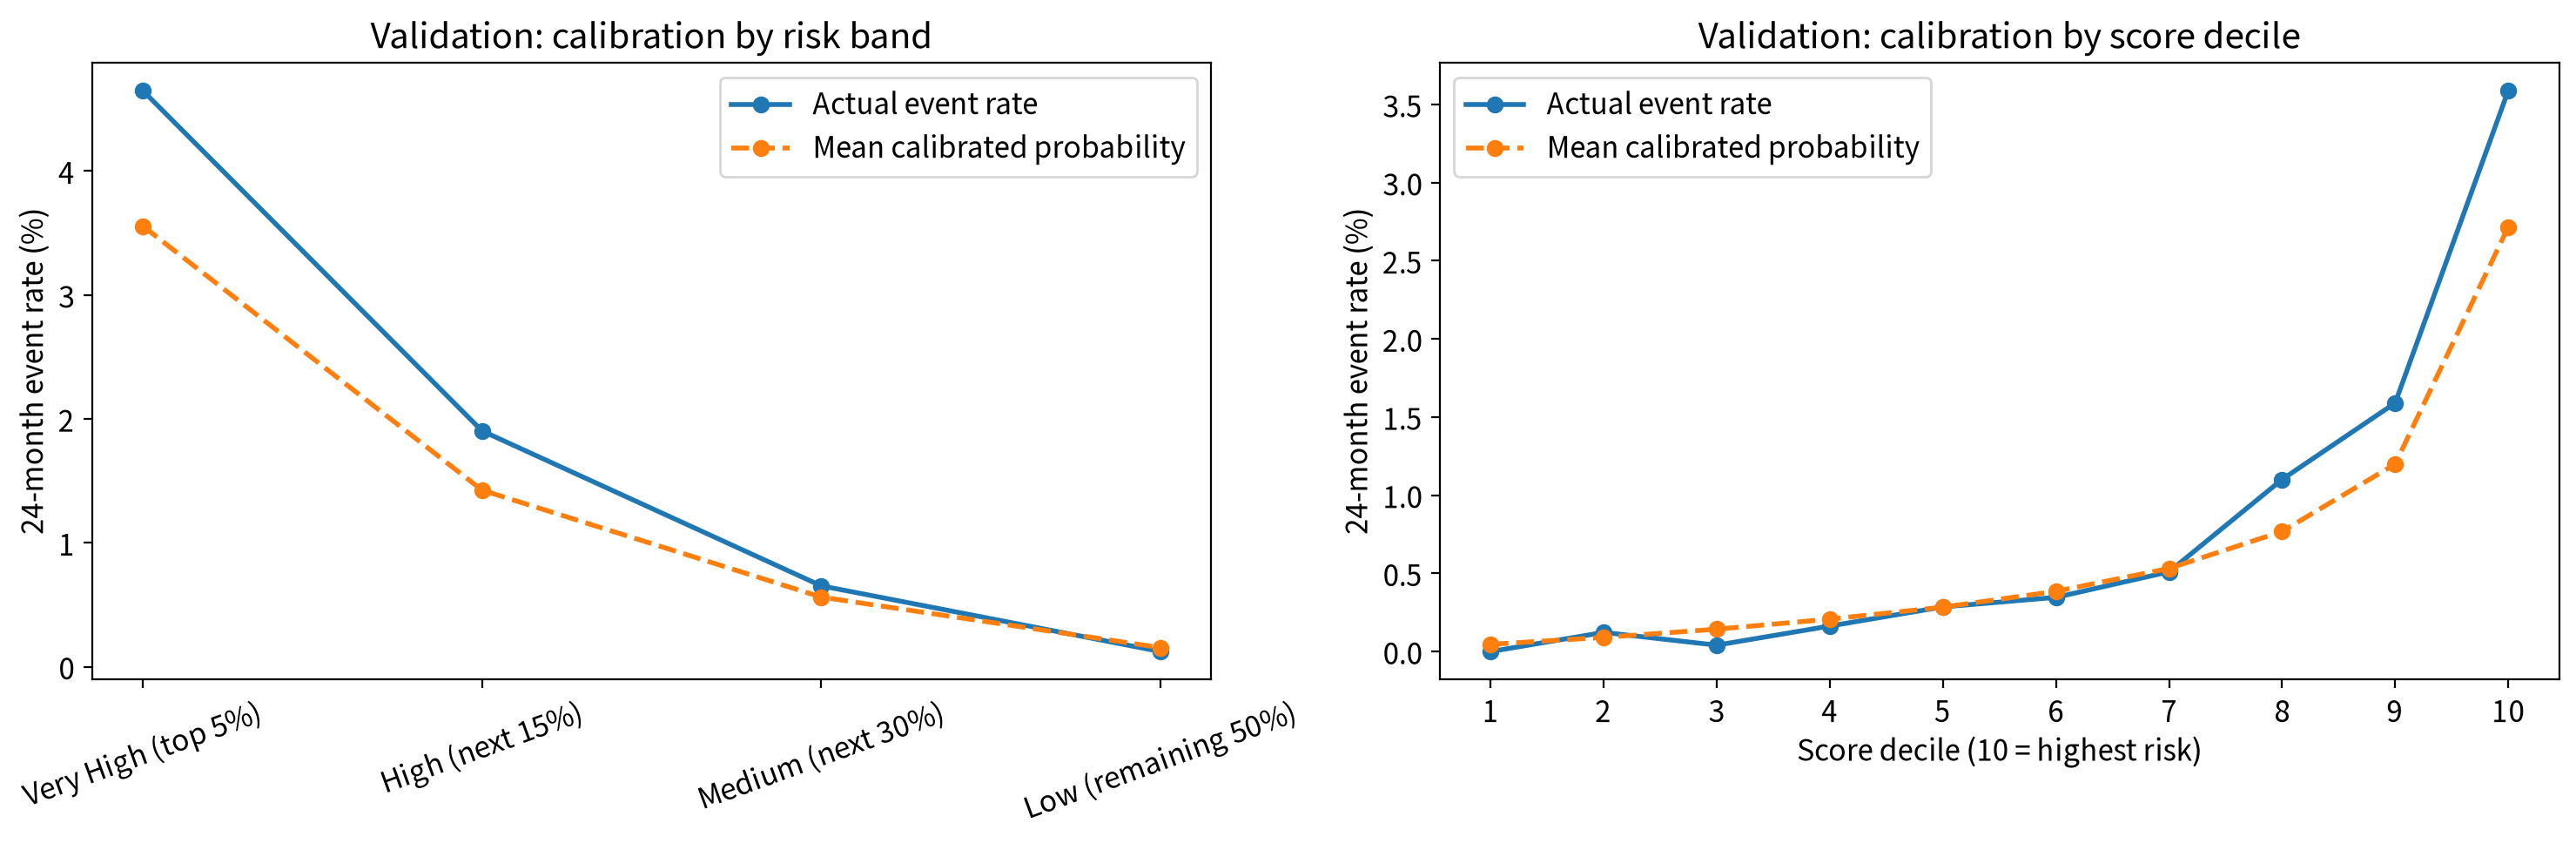

In [13]:
# Evaluate calibration across the chronological Validation cohort.
# Validation labels are used for evaluation only, not for fitting.

validation_check = pd.DataFrame({
    "Loan_ID": validation_df["Loan_ID"].to_numpy(),
    "Target_24M": y_validation.to_numpy(),
    "Raw_Score": validation_scores.to_numpy(),
    "Calibrated_Probability": calibrator.predict_proba(
        logit_scores(validation_scores)
    )[:, 1],
})

# Use the same within-cohort 5% / 15% / 30% / 50% ranking rule.
validation_check["Risk_Band"] = pd.Categorical.from_codes(
    capacity_bands(validation_check["Raw_Score"]),
    categories=BAND_NAMES,
    ordered=True,
)

def calibration_summary(frame, group_column):
    result = (
        frame.groupby(group_column, observed=True)
        .agg(
            Loans=("Target_24M", "size"),
            Actual_Events=("Target_24M", "sum"),
            Actual_Event_Rate=("Target_24M", "mean"),
            Mean_Raw_Score=("Raw_Score", "mean"),
            Mean_Calibrated_Probability=(
                "Calibrated_Probability", "mean"
            ),
            Expected_Events=(
                "Calibrated_Probability", "sum"
            ),
        )
        .reset_index()
    )

    result["Gap_pp"] = 100 * (
        result["Actual_Event_Rate"]
        - result["Mean_Calibrated_Probability"]
    )

    result["Observed_to_Expected"] = (
        result["Actual_Events"]
        / result["Expected_Events"]
    )

    return result


# 1. Four operational risk bands.
band_calibration = calibration_summary(
    validation_check, "Risk_Band"
)

print("VALIDATION: FOUR RISK BANDS")
display(band_calibration)

band_calibration.to_csv(
    OUT_DIR / "validation_calibration_by_risk_band.csv",
    index=False,
)


# 2. Score deciles: 1 = lowest risk, 10 = highest risk.
validation_check["Score_Decile"] = (
    pd.qcut(
        validation_check["Raw_Score"].rank(method="first"),
        q=10,
        labels=range(1, 11),
    )
    .astype(int)
)

decile_calibration = calibration_summary(
    validation_check, "Score_Decile"
)

print("VALIDATION: SCORE DECILES")
display(decile_calibration)

decile_calibration.to_csv(
    OUT_DIR / "validation_calibration_by_score_decile.csv",
    index=False,
)


# 3. Visual comparison.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(
    band_calibration["Risk_Band"].astype(str),
    100 * band_calibration["Actual_Event_Rate"],
    "o-",
    label="Actual event rate",
)
axes[0].plot(
    band_calibration["Risk_Band"].astype(str),
    100 * band_calibration["Mean_Calibrated_Probability"],
    "o--",
    label="Mean calibrated probability",
)
axes[0].set_title("Validation: calibration by risk band")
axes[0].set_ylabel("24-month event rate (%)")
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend()

axes[1].plot(
    decile_calibration["Score_Decile"],
    100 * decile_calibration["Actual_Event_Rate"],
    "o-",
    label="Actual event rate",
)
axes[1].plot(
    decile_calibration["Score_Decile"],
    100 * decile_calibration["Mean_Calibrated_Probability"],
    "o--",
    label="Mean calibrated probability",
)
axes[1].set_title("Validation: calibration by score decile")
axes[1].set_xlabel("Score decile (10 = highest risk)")
axes[1].set_ylabel("24-month event rate (%)")
axes[1].set_xticks(range(1, 11))
axes[1].legend()

fig.tight_layout()
fig.savefig(
    OUT_DIR / "validation_calibration_by_band_and_decile.png",
    dpi=160,
)
plt.show()

## 신규 대출의 24개월 신용위험 평가: 고정 위험 척도와 검증 근거

### 1. 신규 대출은 어떻게 즉시 평가하는가?

신규 대출이 접수될 때는 향후 유입될 전체 대출의 점수 분포를 알 수 없다. 따라서 신규 대출을 미래 대출 집단 내에서 순위화하는 대신, **과거 학습 표본의 점수 분포로 미리 확정한 경계값**과 비교한다.

`신규 대출의 10개 변수 → 저장된 CatBoost 모델 → 위험 점수 → 고정 경계값 비교 → 위험 등급`

경계값은 저장된 동일 모델로 과거 내부 학습 표본 `X_fit`의 128,002건을 채점한 뒤, 점수의 95·80·50백분위수에서 정했다. 신규 대출의 점수만 있으면 다른 신규 대출을 기다리지 않고 등급을 부여할 수 있다.

| 위험 등급 | 고정 모델 점수 기준 | 내부 보류 검증 표본의 실제 24개월 사건율 |
|---|---:|---:|
| Very High | ≥ 0.021036 | 4.231% (63/1,489) |
| High | ≥ 0.007712, < 0.021036 | 1.562% (75/4,801) |
| Medium | ≥ 0.002666, < 0.007712 | 0.371% (36/9,702) |
| Low | < 0.002666 | 0.0625% (10/16,009) |

경계값은 **학습 표본의 점수**로 결정했고, 표의 사건율은 모델 적합에 사용하지 않은 **내부 보류 검증 표본**에서 확인했다. 따라서 등급을 정하는 과정에서 해당 검증 표본의 정답을 사용하지 않았다. 등급별 사건율은 위험 수준에 따라 단조롭게 증가한다.

### 2. 개별 대출의 결과는 어떻게 해석하는가?

예를 들어 대출 `F17Q10100616`의 모델 점수는 **0.221618**이다. 이는 Very High 경계값 0.021036을 초과하며, 과거 기준 표본의 약 **99.9859%**보다 높거나 같은 점수에 해당한다. 따라서 해당 대출은 과거 기준에 비추어 **Very High 등급**이다.

이때 다음 수치는 서로 다른 의미를 가진다.

- **모델 점수 0.221618:** 위험 순위와 등급 판정에 사용하는 값이다.
- **과거 동일 등급의 사건율 4.231%:** Very High 등급 전체의 관측 평균이며, 이 대출 한 건의 확정된 사건 확률이 아니다.
- **보정된 확률 추정치 25.2981%:** 개별 대출에 대한 보정 모델의 출력이다. 다만 시간외 검증에서 고위험 구간의 실제 사건율이 평균 예측 확률보다 높았으므로, 이를 정확성이 입증된 개별 확률로 해석할 수 없다.

### 3. 시간외 검증은 무엇을 뒷받침하는가?

2017년 4월부터 2018년 3월까지의 후속 대출 49,038건에서 모델의 ROC-AUC는 **0.8253**이었다. 해당 기간의 점수를 집단 내부에서 순위화했을 때, 상위 5% 대출은 전체 관측 사건 380건 중 **114건(30.0%)**을 포함했다. 이는 모델의 **상대적 위험 순위화 능력**을 뒷받침한다.

다만 이 상위 5% 결과는 Validation 집단 **내부 백분위수**에 따른 것이다. 앞 표의 **고정 점수 경계값**을 적용한 결과와 동일한 수치로 취급해서는 안 된다. 고정 경계값의 시간외 성능은 해당 경계값을 Validation 대출에 그대로 적용한 뒤, 등급별 대출 수와 실제 사건율을 별도로 집계하여 검증한다.

## 신용위험 등급화 방법의 한계와 적용 범위

1. **위험 등급 경계값은 분석 목적에 따라 설정한 기준이다.** 과거 점수의 95·80·50백분위수를 사용하면 신규 대출에도 일관된 등급을 즉시 부여할 수 있다. 그러나 상위 5%가 최적의 심사 규모라는 뜻은 아니다. 실제 활용 시에는 월별 검토 가능 건수와 운영 비용을 함께 고려해야 한다.

2. **경계값은 모델이 학습한 표본의 점수 분포에서 산출했다.** 동일한 저장 모델의 점수 척도를 신규 대출에 적용할 수 있다는 장점이 있지만, 학습 표본의 점수 분포는 새로운 대출의 분포와 다를 수 있다. 따라서 내부 보류 검증 표본과 이후 발행된 Validation 대출에 **정확히 동일한 고정 경계값**을 적용하여 등급별 건수와 사건율을 확인해야 한다.

3. **등급별 관측 사건율은 개별 대출의 확률이 아니다.** 내부 보류 검증 표본에서 Very High 등급의 24개월 사건율은 4.231%(63/1,489)였다. 이 값은 해당 등급 전체의 평균이다. 경계값을 막 넘은 대출과 매우 높은 점수를 받은 대출에 동일한 개별 사건 확률을 부여할 수는 없다.

4. **개별 대출의 절대 확률은 아직 충분히 검증되지 않았다.** 시간외 Validation에서 상위 5% 대출의 실제 사건율은 4.649%였지만, 보정 후 평균 예측 확률은 3.557%였다. 최고 위험 10분위에서도 실제 사건율 3.589%가 보정 후 예측 확률 2.716%보다 높았다. 따라서 현재 결과는 **상대적 위험 순위와 등급 구분**을 뒷받침하지만, 고위험 대출의 개별 확률이 정확하다는 근거는 되지 않는다. 등급별 PD 보정은 위험 순위 검증과 별도로 다루어야 한다.  
   *출처: Tasche, “The Art of Probability-of-Default Curve Calibration,” 2012, https://arxiv.org/abs/1212.3716*

5. **2017–2018년 시간외 검증은 모든 미래 경제 환경을 대표하지 않는다.** 주택가격과 실업률 관련 변수를 사용하므로, 신규 대출을 평가할 때는 해당 시점에 실제로 발표되어 이용 가능한 자료만 입력해야 한다. 현재 검증 결과만으로 새로운 경기 침체나 금리 환경에서도 같은 성능이 유지된다고 단정할 수 없다.  
   *출처: Sirignano et al., “Deep Learning for Mortgage Risk,” 2016, https://arxiv.org/abs/1607.02470*

6. **예측 대상과 관측 가능 표본을 명확히 정의해야 한다.** 모델의 대상은 이 프로젝트에서 정의한 `Target_24M=1`, 즉 최초 상환 시점 이후 24개월 이내의 중대한 신용 사건이다. 이를 별도의 정의 확인 없이 규제상 ‘디폴트’와 동일하게 표현해서는 안 된다. 조기상환과 관측 종료에 대한 처리 방식도 24개월 사건율의 해석에 영향을 준다.  
   *출처: FHFA, “Patterns of Default and Prepayment for Prime and Nonprime Mortgages,” 2002, https://www.fhfa.gov/research/papers/wp0201*

> **최종 적용 범위:** 본 모델은 대출 실행 시점에 이용 가능한 정보를 바탕으로 향후 24개월의 중대한 신용 사건 위험을 **점수화·순위화·등급화**하는 도구이다. 과거 점수 분포에서 등급 경계값을 고정하고 이후 발행된 대출에서 순위 및 등급별 사건율을 검증했다. 현재는 위험 관리의 우선순위 설정에 활용할 수 있으며, 개별 대출의 절대 사건 확률을 의사결정에 사용하려면 추가적인 시간외 확률 보정과 검증이 필요하다.

In [14]:
## 참고
# https://www.bis.org/committees/bcbs/basel-framework/basel-framework.pdf
# https://www.bis.org/publications/studies-validation-internal-rating-systems-revised.pdf
# https://scikit-learn.org/stable/modules/generated/sklearn.calibration.CalibratedClassifierCV?

In [15]:
import json
import numpy as np
import pandas as pd

# ============================================================
# 1. Freeze the score scale from the saved model's fit cohort
# ============================================================

reference_scores = estimator.predict_proba(
    X_fit[model_features]
)[:, 1]

reference_sorted = np.sort(reference_scores)

cutoff_95 = float(np.quantile(reference_scores, 0.95))
cutoff_80 = float(np.quantile(reference_scores, 0.80))
cutoff_50 = float(np.quantile(reference_scores, 0.50))

cutoffs = {
    "Very High": cutoff_95,
    "High": cutoff_80,
    "Medium": cutoff_50,
}

print("Frozen score boundaries:", cutoffs)


def assign_risk_band(score):
    if score >= cutoff_95:
        return "Very High"
    if score >= cutoff_80:
        return "High"
    if score >= cutoff_50:
        return "Medium"
    return "Low"


# ============================================================
# 2. Estimate historical event rates on the internal holdout
#    These are group reference rates, not individual probabilities.
# ============================================================

holdout_reference = pd.DataFrame({
    "Target_24M": y_holdout.to_numpy(),
    "Model_Risk_Score": holdout_scores.to_numpy(),
})

holdout_reference["Risk_Band"] = holdout_reference[
    "Model_Risk_Score"
].map(assign_risk_band)

band_order = ["Very High", "High", "Medium", "Low"]

historical_band_rates = (
    holdout_reference.groupby("Risk_Band")
    .agg(
        Historical_Loans=("Target_24M", "size"),
        Historical_Events=("Target_24M", "sum"),
        Historical_Event_Rate=("Target_24M", "mean"),
    )
    .reindex(band_order)
)

display(historical_band_rates)

historical_band_rates.to_csv(
    OUT_DIR / "frozen_band_historical_holdout_rates.csv"
)


# ============================================================
# 3. Freeze and save the rule
# ============================================================

rule = {
    "model_file": MODEL_PATH.name,
    "reference": "Train cohort internal 80% fit subset",
    "reference_loans": int(len(X_fit)),
    "very_high_min_score": cutoff_95,
    "high_min_score": cutoff_80,
    "medium_min_score": cutoff_50,
    "score_interpretation": "Model score; not a verified individual probability",
}

rule_path = OUT_DIR / "frozen_10F_risk_scale.json"
rule_path.write_text(
    json.dumps(rule, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

print("Saved rule:", rule_path)


# ============================================================
# 4. Score Validation as incoming loans
#    Target_24M is not used for scoring or band assignment.
# ============================================================

X_incoming = validation_df[model_features].copy()

for col in CATEGORICAL_10F:
    if not isinstance(X_incoming[col].dtype, pd.CategoricalDtype):
        raise TypeError(f"Categorical dtype is missing: {col}")

incoming_scores = estimator.predict_proba(X_incoming)[:, 1]

# Historical position: fraction of reference scores <= new score.
historical_percentile = (
    np.searchsorted(
        reference_sorted,
        incoming_scores,
        side="right",
    )
    / len(reference_sorted)
)

incoming_result = validation_df[
    ["Loan_ID", "First_Payment_Date"]
].copy()

incoming_result["Model_Risk_Score"] = incoming_scores
incoming_result["Historical_Score_Percentile"] = historical_percentile
incoming_result["Risk_Band"] = [
    assign_risk_band(score) for score in incoming_scores
]

# Attach the internal holdout's observed rate for each historical band.
incoming_result["Historical_Band_Event_Rate"] = (
    incoming_result["Risk_Band"]
    .map(historical_band_rates["Historical_Event_Rate"])
)

incoming_result["Historical_Band_Loans"] = (
    incoming_result["Risk_Band"]
    .map(historical_band_rates["Historical_Loans"])
)

# Optional: include the previously fitted sigmoid estimate.
# This estimate was still low on chronological Validation.
if "calibrator" in globals():
    incoming_result["Estimated_24M_Event_Probability"] = (
        calibrator.predict_proba(
            logit_scores(incoming_scores)
        )[:, 1]
    )

incoming_result = incoming_result.sort_values(
    "Model_Risk_Score",
    ascending=False,
    kind="stable",
).reset_index(drop=True)

display(incoming_result.head(20))

output_path = OUT_DIR / "validation_as_incoming_loans_frozen_scale.csv"
incoming_result.to_csv(output_path, index=False)

print(f"Saved {len(incoming_result):,} loans:", output_path)

Frozen score boundaries: {'Very High': 0.02103580814305749, 'High': 0.007711526703438756, 'Medium': 0.0026659397474547855}


,Historical_Loans,Historical_Events,Historical_Event_Rate
Risk_Band,,,
Very High,1489,63,0.042310
High,4801,75,0.015622
Medium,9702,36,0.003711
Low,16009,10,0.000625


Saved rule: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\notebooks\SFLLD_M8_11F_DTI_Missing_3models_controlled_fixed12Fparams\importance\ranking_validation\frozen_10F_risk_scale.json


,Loan_ID,First_Payment_Date,Model_Risk_Score,Historical_Score_Percentile,Risk_Band,Historical_Band_Event_Rate,Historical_Band_Loans,Estimated_24M_Event_Probability
0,F17Q10100616,2017-04-01,0.221618,0.999859,Very High,0.04231,1489,0.252981
1,F17Q10247304,2017-05-01,0.128258,0.999352,Very High,0.04231,1489,0.144605
2,F17Q20077223,2017-06-01,0.119670,0.999250,Very High,0.04231,1489,0.134609
3,F18Q10258204,2018-03-01,0.119478,0.999250,Very High,0.04231,1489,0.134385
4,F17Q20056488,2017-06-01,0.115084,0.999172,Very High,0.04231,1489,0.129273
5,F17Q10233797,2017-05-01,0.103019,0.998930,Very High,0.04231,1489,0.115250
6,F17Q30009589,2017-09-01,0.102221,0.998914,Very High,0.04231,1489,0.114323
7,F17Q10247768,2017-05-01,0.099645,0.998852,Very High,0.04231,1489,0.111333
8,F17Q20173110,2017-07-01,0.099181,0.998836,Very High,0.04231,1489,0.110794
9,F17Q20122606,2017-07-01,0.096921,0.998773,Very High,0.04231,1489,0.108172


Saved 49,038 loans: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\notebooks\SFLLD_M8_11F_DTI_Missing_3models_controlled_fixed12Fparams\importance\ranking_validation\validation_as_incoming_loans_frozen_scale.csv


### 10F CatBoost 모델의 시간 외 검증 결과와 해석

본 연구에서는 먼저 상대적으로 이른 시기에 실행된 대출 160,003건을 80% 학습 데이터와 20% 내부 테스트 데이터로 무작위 분할하였다. 학습 데이터에서 10개 변수로 구성된 CatBoost 모델을 개발하고 내부 테스트를 진행한 뒤, 이후 시기에 실행된 별도의 Validation 대출에 적용하였다.

Validation 데이터에서 **ROC-AUC는 0.8253**이었다. 이는 해당 후속 대출 집단에서 모델이 실제 24개월 신용위험 사건 발생 대출을 비발생 대출보다 대체로 높은 위험 점수로 **순위화할 수 있었음**을 보여준다. 다만 이 결과만으로 개별 대출의 예측 확률이 정확하다고 판단하거나, 다른 경제 환경에서도 동일한 성능이 유지된다고 단정할 수는 없다.

결과를 해석할 때는 다음 조건을 확인해야 한다.

1. **Validation의 독립성:** 변수 조합, 하이퍼파라미터, 임계값 또는 위험 구간을 Validation 결과에 맞춰 반복적으로 수정했다면, 이를 완전히 독립적인 최종 시간 외 검증으로 표현해서는 안 된다. 이 경우에는 시간 외 데이터에 기반한 모델 비교 결과라고 명시한다.
2. **변수의 시점 적합성:** 주택가격 상승률과 실업률 변화 등 모든 입력 변수는 해당 대출의 평가 시점에 실제로 이용 가능했던 값이어야 한다. 결측치 대체값과 범주 인코딩 등 데이터에서 학습되는 전처리 규칙도 학습 데이터에서 결정한 후 Validation에 동일하게 적용해야 한다.
3. **관측 기간과 데이터 분리:** 각 대출의 `Target_24M`을 판정할 수 있도록 24개월 관측 기간이 확보되어야 하며, 학습·테스트·Validation 간 동일 대출 또는 관련 정보의 누출이 없어야 한다.
4. **모델 파일과 평가 결과의 일치:** ROC-AUC 0.8253이 어느 저장 모델(`.pkl`)에서 산출되었는지 기록해야 한다. 이후 전체 160,003건으로 모델을 재학습했다면, 기존 모델의 Validation 성능을 재학습 모델의 성능으로 그대로 표시할 수 없다.

따라서 본 결과의 핵심 결론은 **“10F CatBoost 모델이 이번 후속 실행 대출 집단에서 위험 순위화 성능을 유지했다”**는 것이다. 반면 최고위험 구간에서는 실제 사건율이 평균 예측 확률보다 높게 나타났으므로, 개별 대출의 절대적 사건 확률을 제시할 때에는 추가적인 보정과 별도의 후속 검증이 필요하다.

In [16]:
# Risk-band profiles using the previously frozen score boundaries.
# Run after X_holdout, y_holdout, holdout_scores,
# validation_df, y_validation, validation_scores, and OUT_DIR are defined.

import numpy as np
import pandas as pd
from IPython.display import display

FROZEN_CUTOFFS = {
    "Very High": 0.02103580814305749,
    "High": 0.007711526703438756,
    "Medium": 0.0026659397474547855,
}
BAND_ORDER = ["Very High", "High", "Medium", "Low"]

def make_profile(frame, labels, scores, dataset_name):
    if not frame.index.equals(labels.index) or not frame.index.equals(scores.index):
        raise ValueError(f"{dataset_name}: row indices are not aligned")

    required = [
        "FICO_Score", "Original_CLTV",
        "Number_of_Borrowers", "DTI_Missing",
    ]
    missing = sorted(set(required) - set(frame.columns))
    if missing:
        raise KeyError(f"{dataset_name}: missing columns {missing}")

    data = frame[required].copy()
    data["Target_24M"] = labels.astype(int)
    data["Model_Risk_Score"] = scores.astype(float)

    data["Risk_Band"] = np.select(
        [
            data["Model_Risk_Score"] >= FROZEN_CUTOFFS["Very High"],
            data["Model_Risk_Score"] >= FROZEN_CUTOFFS["High"],
            data["Model_Risk_Score"] >= FROZEN_CUTOFFS["Medium"],
        ],
        ["Very High", "High", "Medium"],
        default="Low",
    )
    data["Risk_Band"] = pd.Categorical(
        data["Risk_Band"], categories=BAND_ORDER, ordered=True
    )

    # Convert categorical 0/1 labels to numeric values for proportions.
    data["DTI_Missing_01"] = pd.to_numeric(
        data["DTI_Missing"].astype(str), errors="raise"
    )
    if not data["DTI_Missing_01"].isin([0, 1]).all():
        raise ValueError("DTI_Missing contains values other than 0 and 1")

    data["Single_Borrower"] = (
        pd.to_numeric(data["Number_of_Borrowers"], errors="raise") == 1
    ).astype(int)

    profile = (
        data.groupby("Risk_Band", observed=False)
        .agg(
            Loans=("Target_24M", "size"),
            Events=("Target_24M", "sum"),
            Actual_Event_Rate=("Target_24M", "mean"),
            Mean_Model_Score=("Model_Risk_Score", "mean"),
            FICO_Median=("FICO_Score", "median"),
            FICO_Q25=("FICO_Score", lambda s: s.quantile(0.25)),
            FICO_Q75=("FICO_Score", lambda s: s.quantile(0.75)),
            CLTV_Median=("Original_CLTV", "median"),
            CLTV_Q25=("Original_CLTV", lambda s: s.quantile(0.25)),
            CLTV_Q75=("Original_CLTV", lambda s: s.quantile(0.75)),
            Single_Borrower_Share=("Single_Borrower", "mean"),
            DTI_Missing_Share=("DTI_Missing_01", "mean"),
        )
        .reset_index()
    )

    profile.insert(0, "Dataset", dataset_name)
    profile["Loan_Share"] = profile["Loans"] / len(data)
    profile["Event_Capture"] = (
        profile["Events"] / data["Target_24M"].sum()
    )
    profile["Event_Rate_Lift"] = (
        profile["Actual_Event_Rate"] / data["Target_24M"].mean()
    )

    return profile

holdout_profile = make_profile(
    X_holdout, y_holdout, holdout_scores, "Internal Test"
)

validation_profile = make_profile(
    validation_df, y_validation, validation_scores,
    "Chronological Validation"
)

risk_band_profile = pd.concat(
    [holdout_profile, validation_profile], ignore_index=True
)

display(
    risk_band_profile.style.format({
        "Loan_Share": "{:.1%}",
        "Actual_Event_Rate": "{:.3%}",
        "Event_Capture": "{:.1%}",
        "Mean_Model_Score": "{:.4%}",
        "FICO_Median": "{:.0f}",
        "FICO_Q25": "{:.0f}",
        "FICO_Q75": "{:.0f}",
        "CLTV_Median": "{:.0f}",
        "CLTV_Q25": "{:.0f}",
        "CLTV_Q75": "{:.0f}",
        "Single_Borrower_Share": "{:.1%}",
        "DTI_Missing_Share": "{:.1%}",
        "Event_Rate_Lift": "{:.2f}x",
    })
)

output_path = OUT_DIR / "frozen_risk_band_loan_profiles.csv"
risk_band_profile.to_csv(output_path, index=False)
print("Saved:", output_path)

,Dataset,Risk_Band,Loans,Events,Actual_Event_Rate,Mean_Model_Score,FICO_Median,FICO_Q25,FICO_Q75,CLTV_Median,CLTV_Q25,CLTV_Q75,Single_Borrower_Share,DTI_Missing_Share,Loan_Share,Event_Capture,Event_Rate_Lift
0,Internal Test,Very High,1489,63,4.231%,3.7138%,663,640,690,90,78,97,82.8%,47.1%,4.7%,34.2%,7.36x
1,Internal Test,High,4801,75,1.562%,1.2250%,697,673,722,80,74,95,71.0%,19.1%,15.0%,40.8%,2.72x
2,Internal Test,Medium,9702,36,0.371%,0.4537%,739,710,772,80,71,90,63.0%,8.8%,30.3%,19.6%,0.65x
3,Internal Test,Low,16009,10,0.062%,0.1264%,780,759,797,75,60,80,32.5%,4.3%,50.0%,5.4%,0.11x
4,Chronological Validation,Very High,2704,124,4.586%,3.2283%,662,642,686,80,73,95,86.3%,13.9%,5.5%,32.6%,5.92x
5,Chronological Validation,High,9593,163,1.699%,1.2376%,701,679,724,80,74,95,72.6%,5.3%,19.6%,42.9%,2.19x
6,Chronological Validation,Medium,16776,77,0.459%,0.4634%,745,716,775,80,73,90,63.7%,2.6%,34.2%,20.3%,0.59x
7,Chronological Validation,Low,19965,16,0.080%,0.1368%,780,760,797,75,60,80,29.8%,1.4%,40.7%,4.2%,0.10x


Saved: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\notebooks\SFLLD_M8_11F_DTI_Missing_3models_controlled_fixed12Fparams\importance\ranking_validation\frozen_risk_band_loan_profiles.csv


### 고정 위험등급별 대출 특성 및 시간 외 검증 결과

저장된 10F CatBoost 모델의 **고정 점수 경계**를 내부 테스트 데이터와 이후 실행된 Validation 데이터에 동일하게 적용하였다. 따라서 각 등급의 대출 비율은 데이터마다 정확히 5%·15%·30%·50%로 맞춰지지 않는다.

| 위험등급 | 내부 테스트 사건율 | Validation 사건율 | Validation FICO 중앙값 | Validation 단독 차주 비율 |
|:---|---:|---:|---:|---:|
| Very High | 4.231% | **4.586%** | 662 | 86.3% |
| High | 1.562% | **1.699%** | 701 | 72.6% |
| Medium | 0.371% | **0.459%** | 745 | 63.7% |
| Low | 0.062% | **0.080%** | 780 | 29.8% |

**위험등급이 높을수록 실제 사건율이 높게 나타나는 순서가 두 데이터에서 모두 유지되었다.** Validation에서 Very High와 High에 속한 대출은 총 **12,297건(전체의 25.1%)**이며, 이 두 등급에서 **전체 사건 380건 중 287건(75.5%)**이 발생했다. 이는 고정 등급을 대출 검토의 우선순위 설정에 활용할 수 있음을 뒷받침한다.

대출 특성에서도 뚜렷한 차이가 나타났다. Validation의 FICO 중앙값은 Very High의 **662점**에서 Low의 **780점**으로 높아졌으며, 단독 차주 비율은 **86.3%에서 29.8%**로 낮아졌다. 이는 등급별 *관찰된 특성 차이*이며, FICO나 차주 수의 인과효과를 의미하지는 않는다.

다만 **DTI 결측 비율은 시기별로 크게 달랐다.** Very High 등급에서 내부 테스트의 결측 비율은 **47.1%**, Validation에서는 **13.9%**였다. 대출 구성 또는 결측 발생 과정의 변화 가능성이 있으므로, 발행 시기와 관련 대출 특성을 함께 확인할 필요가 있다.

또한 Validation의 Very High 등급은 **실제 사건율 4.586%**에 비해 **평균 원시 모델 점수 3.228%**로 낮았고, High 등급도 **1.699% 대 1.238%**였다. 따라서 이번 결과는 **위험 순위화와 사건 집중 능력은 유지되지만, 고위험 등급의 절대 확률은 과소추정될 수 있음**을 보여준다.

> **해석 시 주의:** 본 표는 고정된 *점수 경계*로 분류한 결과이다. Validation 내부에서 점수 상위 5%를 다시 선정한 결과(2,452건·사건 114건)와는 분류 방식이 다르므로 혼용해서는 안 된다.

### 고정 위험등급별 대출 특성 — 시간 외 Validation

| 위험등급 | 대출 건수 | 실제 24개월 사건율 | FICO 중앙값 | CLTV 중앙값 | 단독 차주 비율 | DTI 결측 비율 |
| --- | ---: | ---: | ---: | ---: | ---: | ---: |
| **Very High** | 2,704 | **4.586%** | **662** | 80 | **86.3%** | 13.9% |
| **High** | 9,593 | **1.699%** | 701 | 80 | 72.6% | 5.3% |
| **Medium** | 16,776 | **0.459%** | 745 | 80 | 63.7% | 2.6% |
| **Low** | 19,965 | **0.080%** | **780** | 75 | **29.8%** | 1.4% |

- **Very High:** FICO 점수가 가장 낮고, 단독 차주 비율과 DTI 결측 비율이 가장 높다.
- **High:** FICO 점수가 비교적 낮으며 단독 차주가 다수를 차지한다.
- **Medium:** FICO 점수가 높아지고 단독 차주 및 DTI 결측 비율이 감소한다.
- **Low:** FICO 점수가 가장 높고, 공동 차주 대출의 비중이 상대적으로 크다. CLTV 중앙값도 다른 등급보다 낮다.

**핵심 해석:** 위험등급이 낮아질수록 FICO 중앙값은 **662점에서 780점으로 증가**하고, 단독 차주 비율은 **86.3%에서 29.8%로 감소**한다. 반면 CLTV 중앙값은 상위 세 등급 모두 **80**이므로, 특정 등급을 한 변수만으로 설명해서는 안 된다. 각 등급은 **10개 변수의 조합으로 산출된 모델 점수**에 따라 결정된다.